# 01 逐时共享岭回归与整日残差情景

输入为目标时刻、日历周期、前1/7天同一时刻负荷与光伏及近7日均值；输出为下一日144点负荷/PV中心曲线。概率场景由历史整日成对残差叠加得到。

所有结果只保存在 Notebook 输出中，不写出图片、表格或缓存文件。预测评价期为 2025-02-01 至 2025-12-31；题目给定的初始储能为 6000 kWh，但本 Notebook 只评价预测层，因此不计算调度费用。

In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "C题.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = pd.read_csv(ROOT / "q2/input/q2_actual_load_pv.csv", encoding="utf-8-sig")
DATES = pd.DatetimeIndex(pd.to_datetime(DATA["date"].drop_duplicates()))
LOAD = DATA["load_kw"].to_numpy(float).reshape(-1, 144)
PV = DATA["pv_kw"].to_numpy(float).reshape(-1, 144)
EVAL_START = pd.Timestamp("2025-02-01")
EVAL_IDX = np.where(DATES >= EVAL_START)[0]
SLOTS = np.arange(144)
INITIAL_STORAGE_KWH = 6000.0  # 题目给定的 2025-01-01 00:00 初始储能
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .25})

def crps_ensemble(samples, actual):
    # CRPS = E|X-y| - 1/2 E|X-X'|；排序形式避免构造 S×S 矩阵
    z = np.sort(samples, axis=0)
    s = len(z)
    w = (2*np.arange(1, s+1)-1-s)[:, None]
    return np.abs(z-actual).mean(axis=0) - (w*z).sum(axis=0)/(s*s)

def evaluate_forecast(centres_load, centres_pv, scenario_days):
    rows, q10s, q90s, q05s, q95s = [], [], [], [], []
    for d in EVAL_IDX:
        cnet = centres_load[d] - centres_pv[d]
        actual = LOAD[d] - PV[d]
        scen = scenario_days[d]
        q05, q10, q90, q95 = np.quantile(scen, [.05, .10, .90, .95], axis=0)
        rows.append({
            "date": DATES[d],
            "mae_kw": np.abs(cnet-actual).mean(),
            "rmse_kw": np.sqrt(np.mean((cnet-actual)**2)),
            "crps_kw": crps_ensemble(scen, actual).mean(),
            "cover80": np.mean((actual >= q10) & (actual <= q90)),
            "cover90": np.mean((actual >= q05) & (actual <= q95)),
            "width80_kw": np.mean(q90-q10),
            "width90_kw": np.mean(q95-q05),
        })
        q10s.append(q10); q90s.append(q90); q05s.append(q05); q95s.append(q95)
    daily = pd.DataFrame(rows)
    summary = pd.DataFrame({
        "metric": ["MAE (kW)", "RMSE (kW)", "CRPS (kW)", "80% coverage", "90% coverage", "80% width (kW)", "90% width (kW)"],
        "value": [daily.mae_kw.mean(), daily.rmse_kw.mean(), daily.crps_kw.mean(), daily.cover80.mean(), daily.cover90.mean(), daily.width80_kw.mean(), daily.width90_kw.mean()]
    })
    bands = {"q10": np.array(q10s), "q90": np.array(q90s), "q05": np.array(q05s), "q95": np.array(q95s)}
    return daily, summary, bands

def plot_diagnostics(model_name, centres_load, centres_pv, scenario_days, daily, bands):
    # 指定日概率扇形图
    d = int(np.where(DATES == pd.Timestamp("2025-06-21"))[0][0])
    x = SLOTS / 6
    scen = scenario_days[d]
    q05, q10, q90, q95 = np.quantile(scen, [.05, .10, .90, .95], axis=0)
    center = centres_load[d] - centres_pv[d]
    actual = LOAD[d] - PV[d]
    fig, ax = plt.subplots()
    ax.fill_between(x, q05, q95, alpha=.18, label="90% interval")
    ax.fill_between(x, q10, q90, alpha=.28, label="80% interval")
    ax.plot(x, actual, color="black", lw=1.5, label="actual net load")
    ax.plot(x, center, color="tab:red", lw=1.2, label="center forecast")
    ax.set(title=f"{model_name}: 2025-06-21", xlabel="hour", ylabel="kW")
    ax.legend(ncol=2); plt.show()

    monthly = daily.assign(month=daily.date.dt.month).groupby("month")[["mae_kw", "crps_kw"]].mean()
    monthly.plot(marker="o", title=f"{model_name}: monthly forecast scores", ylabel="kW")
    plt.show()

    cov = [daily.cover80.mean(), daily.cover90.mean()]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["80% interval", "90% interval"], cov, color=["#4c78a8", "#72b7b2"])
    ax.scatter([0, 1], [.8, .9], color="black", zorder=3, label="nominal")
    ax.set_ylim(0, 1); ax.set_ylabel("empirical coverage"); ax.set_title(f"{model_name}: calibration")
    ax.legend(); plt.show()


In [2]:

def row_features(load, pv, dates, day_indices):
    rows = []
    for d in day_indices:
        slot = np.arange(144)
        ang = 2*np.pi*slot/144
        doy = dates[d].dayofyear
        cal = np.column_stack([
            np.sin(ang), np.cos(ang), np.sin(2*ang), np.cos(2*ang),
            np.full(144, np.sin(2*np.pi*doy/365.25)),
            np.full(144, np.cos(2*np.pi*doy/365.25)),
            np.full(144, dates[d].weekday() in (4, 5), dtype=float),
            load[d-1], pv[d-1], load[d-7], pv[d-7],
            load[d-7:d].mean(axis=0), pv[d-7:d].mean(axis=0),
        ])
        rows.append(cal)
    return np.vstack(rows)

centres_load = np.full_like(LOAD, np.nan)
centres_pv = np.full_like(PV, np.nan)
scenario_days, residual_bank = {}, []
start_day, window, alpha = 14, 90, 30.0

for d in range(start_day, len(DATES)):
    train_days = np.arange(max(7, d-window), d)
    X = row_features(LOAD, PV, DATES, train_days)
    Y = np.column_stack([LOAD[train_days].reshape(-1), PV[train_days].reshape(-1)])
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(X, Y)
    pred = model.predict(row_features(LOAD, PV, DATES, [d]))
    centres_load[d] = np.maximum(pred[:, 0], 0)
    centres_pv[d] = np.maximum(pred[:, 1], 0)

    if residual_bank:
        err_l = np.array([x[0] for x in residual_bank[-28:]])
        err_p = np.array([x[1] for x in residual_bank[-28:]])
        ls = np.maximum(centres_load[d][None, :] + err_l, 0)
        ps = np.maximum(centres_pv[d][None, :] + err_p, 0)
        scenario_days[d] = ls - ps
    residual_bank.append((LOAD[d]-centres_load[d], PV[d]-centres_pv[d]))

daily, summary, bands = evaluate_forecast(centres_load, centres_pv, scenario_days)


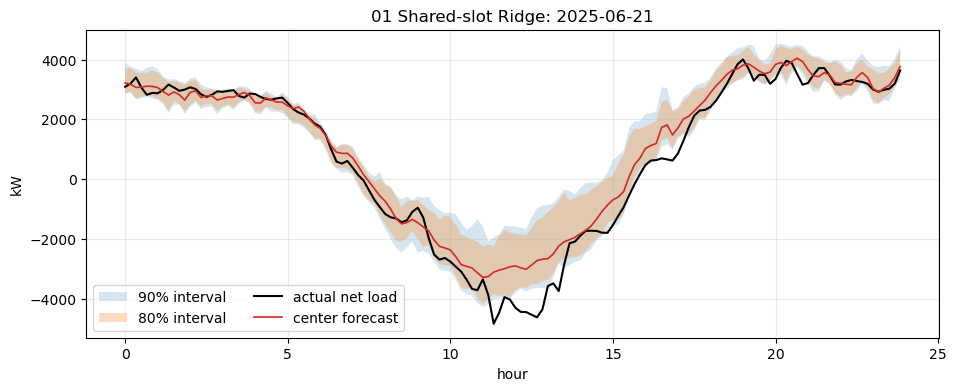

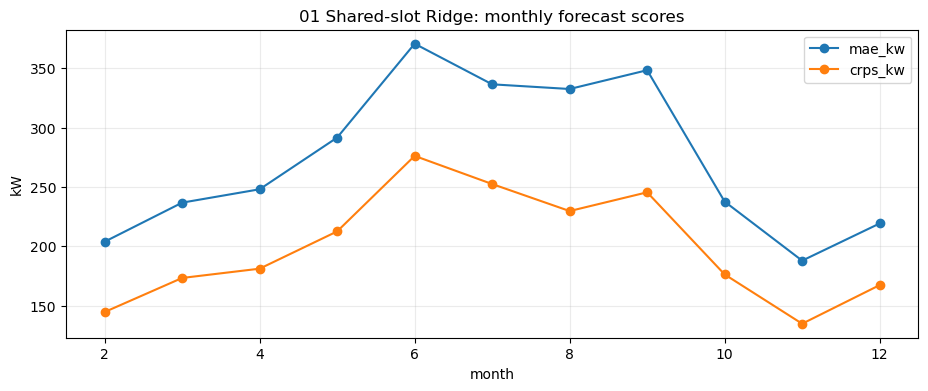

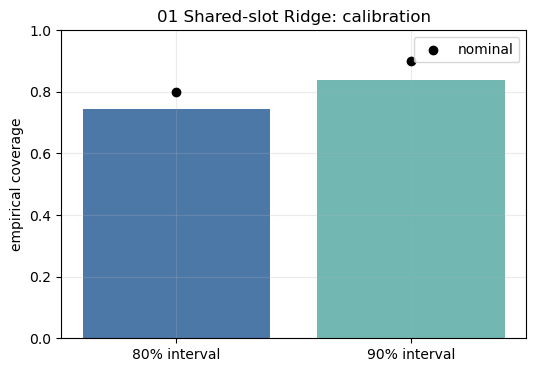

In [3]:
MODEL_NAME="01 Shared-slot Ridge"
plot_diagnostics(MODEL_NAME, centres_load, centres_pv, scenario_days, daily, bands)

## 拟合效果汇总

MAE/RMSE 衡量中心预测误差；CRPS 综合衡量整个概率分布，三者越小越好。覆盖率应分别接近 0.8 和 0.9；区间宽度越小表示预测越尖锐。

In [4]:
summary = summary.copy()
summary.insert(0, 'model', MODEL_NAME)
display(summary.round(4))

,model,metric,value
0,01 Shared-slot Ridge,MAE (kW),274.3806
1,01 Shared-slot Ridge,RMSE (kW),363.9260
2,01 Shared-slot Ridge,CRPS (kW),199.8328
3,01 Shared-slot Ridge,80% coverage,0.7435
4,01 Shared-slot Ridge,90% coverage,0.8372
5,01 Shared-slot Ridge,80% width (kW),812.7095
6,01 Shared-slot Ridge,90% width (kW),1018.7773
